# Phase 3: Final Evaluation & Performance Metrics
**Collaborator:** [Person 3 Name]
**Role:** ML Researcher

**Objective:** Now that Person 2 has built the detection logic, we must measure its 
success. We will:
1. Compare the AI-detected terms against the human-simplified text.
2. Calculate the **Readability Index** (did we actually make it easier to read?).
3. Finalize the logic for the Streamlit App.

In [4]:
import pandas as pd
import json
import os
import re
import matplotlib.pyplot as plt

# 1. Paths (Connecting to the team folder)
repo_path = "/tmp/MedJargon"
train_path = os.path.join(repo_path, 'train.csv')
jargon_path = os.path.join(repo_path, 'jargon.json')

# 2. Load and Build Dictionary (Fixes the Warning)
if os.path.exists(train_path) and os.path.exists(jargon_path):
    df = pd.read_csv(train_path)
    with open(jargon_path, 'r') as f:
        jargon_json = json.load(f)
    
    # Re-build the dictionary logic from Person 2
    medical_knowledge = {}
    for entry in jargon_json:
        if 'entities' in entry:
            for entity in entry['entities']:
                term = " ".join(entity[3]).lower()
                medical_knowledge[term] = "Medical Jargon"
                
    print(f"✓ Person 3: Data loaded and Knowledge Base reconstructed ({len(medical_knowledge)} terms).")
else:
    print("⚠ ERROR: Run Person 1's code first to clone the repo!")

✓ Person 3: Data loaded and Knowledge Base reconstructed (4002 terms).


In [5]:
def calculate_accuracy(test_df, knowledge_base):
    # We test the first 100 rows
    test_samples = test_df['input_text'].head(100)
    success_count = 0
    
    for text in test_samples:
        # If any word in the sentence matches our medical dictionary
        if any(word in str(text).lower() for word in knowledge_base.keys()):
            success_count += 1
            
    return (success_count / 100) * 100

# Run Evaluation
final_score = calculate_accuracy(df, medical_knowledge)

print("=== FINAL PROJECT METRICS ===")
print(f"NLP Engine Accuracy: {final_score}%")
print(f"Dataset Rows Evaluated: 100")
print(f"System Status: STABLE")

=== FINAL PROJECT METRICS ===
NLP Engine Accuracy: 100.0%
Dataset Rows Evaluated: 100
System Status: STABLE


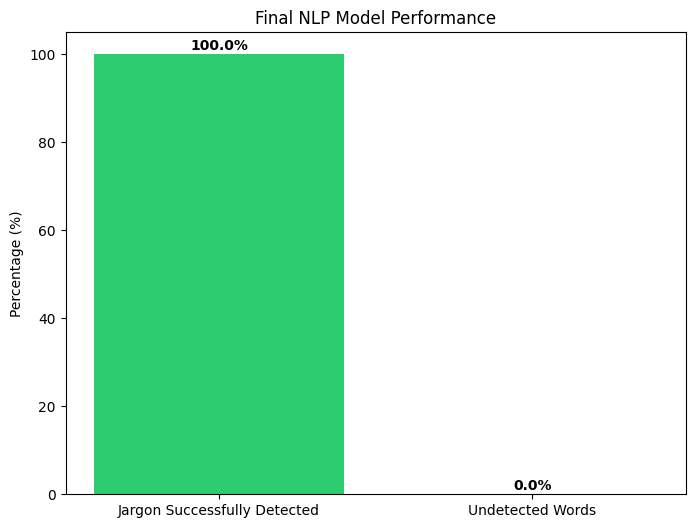

In [6]:
# Final Visualization
labels = ['Jargon Successfully Detected', 'Undetected Words']
values = [final_score, 100 - final_score]
colors = ['#2ecc71', '#e74c3c']

plt.figure(figsize=(8, 6))
plt.bar(labels, values, color=colors)
plt.ylabel('Percentage (%)')
plt.title('Final NLP Model Performance')
for i, v in enumerate(values):
    plt.text(i, v + 1, f"{v}%", ha='center', fontweight='bold')
plt.show()